# GrowthQA — Stage 1 Classifier: Training, Feature Selection & Evaluation (Claude.V03)

This notebook is the working analysis notebook for Thesis Chapter 5 ("Classification Pipeline").
It regenerates `meta.csv` from the two source wide files, trains and compares Stage 1 models
(LR / RF / HGB) across three candidate feature sets, produces the diagnostic plots needed for
the chapter (confusion matrices, ROC, calibration, feature importance, ablation, confidence-threshold
sweep, failure analysis by curve subtype), and finally demonstrates the Stage 1 (≤16 h) + Stage 2
(>16 h evidence) inference flow on two example files.

**Important finding from this session (read first):** while regenerating `meta.csv` from
`timeseries_wide_SD1.csv` + `lab_14.75h_0.25.csv` through the actual repo pipeline
(`growthqa merge-meta`), `source_type` for every one of the 2976 rows came out as `"lab"`,
including the 2700 rows that originate from the *synthetic* file. The cause is in
`src/growthqa/io/wide_loader.py::load_wide_csv`: source detection there is still filename-based
(`"syn" in Path(path).stem.lower()`), and `timeseries_wide_SD1.csv` does not contain the substring
`"syn"`. This is the same mislabelling failure mode described as fixed in earlier notes, but the
content-based fix (using the `Curve Subtype` marker column, which only synthetic rows carry) was not
present in this code path. The fix applied for this notebook is shown in Section 1 and changes
`source_type` to be inferred from `Curve Subtype` when that column is present, falling back to the
filename heuristic otherwise. This is worth a short, honest paragraph in Chapter 5 / Appendix
(reproducibility) since it means any previously reported per-source metrics need to be re-checked
against the corrected labels.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="A single label was found")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.calibration import calibration_curve

from growthqa.classifier.train_from_meta import (
    build_model_matrix, build_models, _group_split, fit_and_eval,
    compute_metrics, NOTEBOOK_STAGE1_CUSTOM_FEATURES, train_from_meta_csv,
    IDENTIFIER_COLS, LEAKAGE_COLS,
)

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = Path(".").resolve()
print(ROOT)

/home/claude/growthqa


## 1. Data provenance: regenerating `meta.csv`

`meta.csv` is not written by hand; it is produced from the two source wide files by
`growthqa merge-meta` (`run_merge_preprocess_meta`). Regenerating it here (rather than trusting a
committed copy) is the only way to be sure the numbers in this notebook match the current state of
the pipeline code, and it is what surfaced the `source_type` bug above.

The command used (`step=0.25`, `tmax_hours=16`, truncation horizons `[8, 10, 12, 14.75, 16]`,
`trunc_per_curve=3`, SGF smoothing with window 5, MINMAX normalization, blank status `ALREADY`) is
the configuration documented in the meta.csv generation note. It reproduces the previously reported
shape of 2976 rows over 992 base curves with a 1842 / 1134 valid/invalid split exactly.

In [2]:
META_CSV = Path("data/regen/meta.csv")
meta = pd.read_csv(META_CSV)

print("meta.csv shape:", meta.shape)
print("base curves:", meta["base_curve_id"].nunique())
print()
print("Label balance:")
print(meta["Is_Valid"].value_counts().rename({1: "Valid", 0: "Invalid"}))
print()
print("Source-type breakdown after the Curve-Subtype-based fix:")
print(meta.groupby("source_type")["Is_Valid"].value_counts().unstack().rename(columns={1: "Valid", 0: "Invalid"}))

meta.csv shape: (2976, 51)
base curves: 992

Label balance:
Is_Valid
Valid      1842
Invalid    1134
Name: count, dtype: int64

Source-type breakdown after the Curve-Subtype-based fix:
Is_Valid     Invalid   Valid
source_type                 
lab              NaN   276.0
synthetic     1134.0  1566.0


## 2. Column classification

`meta.csv` mixes four kinds of columns: curve **identifiers** (never features — they would let a
model memorise a specific curve), **leakage** columns (would give away the answer), columns that are
entirely empty in this run because `--rich-meta` (the parametric AIC/logistic fit columns) was not
requested, and genuine **candidate features**. The production `build_model_matrix()` already drops
identifiers and leakage columns; the all-NaN columns are dropped here explicitly so they don't get
silently median-imputed into constant, meaningless features.

In [3]:
DEAD_COLS = [
    "logistic_fit_mse", "logistic_AIC", "gompertz_AIC",
    "richards_AIC", "flat_AIC", "best_model_AIC", "best_model_name",
]

X, y, groups, feature_cols, eval_df = build_model_matrix(meta, label_col="Is_Valid")
n_before = X.shape[1]
X = X.drop(columns=[c for c in DEAD_COLS if c in X.columns])
feature_cols = [c for c in feature_cols if c not in DEAD_COLS]

print(f"Identifier columns dropped by build_model_matrix: {sorted(IDENTIFIER_COLS)}")
print(f"Leakage columns dropped by build_model_matrix:    {sorted(LEAKAGE_COLS)}")
print(f"All-NaN (rich-meta / not computed) columns dropped here: {DEAD_COLS}")
print(f"Numeric feature matrix: {n_before} -> {X.shape[1]} columns after dropping dead columns")
print()
print("Remaining candidate feature columns:")
print(feature_cols)

Identifier columns dropped by build_model_matrix: ['Concentration', 'FileName', 'Model Name', 'Test Id', 'aug_id', 'base_curve_id']
Leakage columns dropped by build_model_matrix:    ['best_model_name', 'meta_label']
All-NaN (rich-meta / not computed) columns dropped here: ['logistic_fit_mse', 'logistic_AIC', 'gompertz_AIC', 'richards_AIC', 'flat_AIC', 'best_model_AIC', 'best_model_name']
Numeric feature matrix: 43 -> 37 columns after dropping dead columns

Remaining candidate feature columns:
['had_outliers', 'is_synthetic', 'tmax_original', 'train_horizon', 'observed_tmax', 'is_censored', 'n_points_observed', 'max_gap_hours', 'median_dt_hours', 'missing_frac_on_grid', 'low_resolution', 'too_sparse', 'initial_OD', 'final_OD', 'max_OD', 'min_OD', 'range_OD', 'auc', 'auc_per_hour', 'net_change_per_hour', 'max_slope', 'time_of_max_slope', 'time_of_max_OD', 'monotonicity_fraction', 'largest_drop_frac', 'dip_fraction', 'roughness', 'noise_residual_std', 'lag_time', 'lag_time_est', 'plateau_

## 3. Group-aware train / validation / test split

Because each base curve appears at multiple truncation horizons (8 h, 10 h, 12 h, 14.75 h, 16 h),
a naive random split would put different truncations of the *same* curve into both train and test,
which leaks information and inflates reported performance. `_group_split` uses `GroupShuffleSplit`
on `base_curve_id` (60/20/20 train/val/test) to prevent this, and the pipeline explicitly asserts
there is no group overlap between splits.

In [4]:
train_idx, val_idx, test_idx = _group_split(X, y, groups)
overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
assert not overlap, f"Leakage detected: {overlap}"

print("Split sizes (rows):", {"train": len(train_idx), "val": len(val_idx), "test": len(test_idx)})
print("Split sizes (base curves):", {
    "train": groups.iloc[train_idx].nunique(),
    "val": groups.iloc[val_idx].nunique(),
    "test": groups.iloc[test_idx].nunique(),
})
print("Group overlap between train and test:", overlap, "(expected: empty set)")

Split sizes (rows): {'train': 1782, 'val': 597, 'test': 597}
Split sizes (base curves): {'train': 594, 'val': 199, 'test': 199}
Group overlap between train and test: set() (expected: empty set)


## 4. Candidate Stage 1 feature sets

Three sets are compared:

- **FULL** — every remaining numeric candidate feature (the "kitchen sink" baseline).
- **CANDIDATE_10** — the 10-feature set recorded in `train_from_meta.py` as originating from the
  missing `Stage1_Feature_Exploration_Selection_Training_v2.ipynb` notebook.
- **FINAL_8** — the current working set, which drops `auc_per_hour` and `dip_fraction` from the
  10-feature set.

Comparing all three against each other, rather than assuming the smaller set is correct, is what
lets Chapter 5 report the feature-selection decision as an empirical result rather than an
unexamined assumption.

In [5]:
FINAL_8 = [
    "observed_tmax", "net_change_per_hour", "max_slope", "lag_time_est",
    "monotonicity_fraction", "largest_drop_frac", "roughness", "final_to_peak_ratio",
]
CANDIDATE_10 = NOTEBOOK_STAGE1_CUSTOM_FEATURES
FULL = feature_cols

print("FULL          (%d features)" % len(FULL))
print("CANDIDATE_10  (%d features):" % len(CANDIDATE_10), CANDIDATE_10)
print("FINAL_8       (%d features):" % len(FINAL_8), FINAL_8)
print()
print("Dropped going from CANDIDATE_10 to FINAL_8:", sorted(set(CANDIDATE_10) - set(FINAL_8)))

FULL          (37 features)
CANDIDATE_10  (10 features): ['observed_tmax', 'auc_per_hour', 'net_change_per_hour', 'max_slope', 'lag_time_est', 'dip_fraction', 'largest_drop_frac', 'monotonicity_fraction', 'roughness', 'final_to_peak_ratio']
FINAL_8       (8 features): ['observed_tmax', 'net_change_per_hour', 'max_slope', 'lag_time_est', 'monotonicity_fraction', 'largest_drop_frac', 'roughness', 'final_to_peak_ratio']

Dropped going from CANDIDATE_10 to FINAL_8: ['auc_per_hour', 'dip_fraction']


## 5. Correlation structure among candidate features

`max_slope` and `roughness` were noted as collinear (r ≈ 0.87). The heatmap below checks this on the
regenerated data and also looks at `noise_residual_std`, which was flagged as a possible
lower-redundancy alternative to `roughness`.

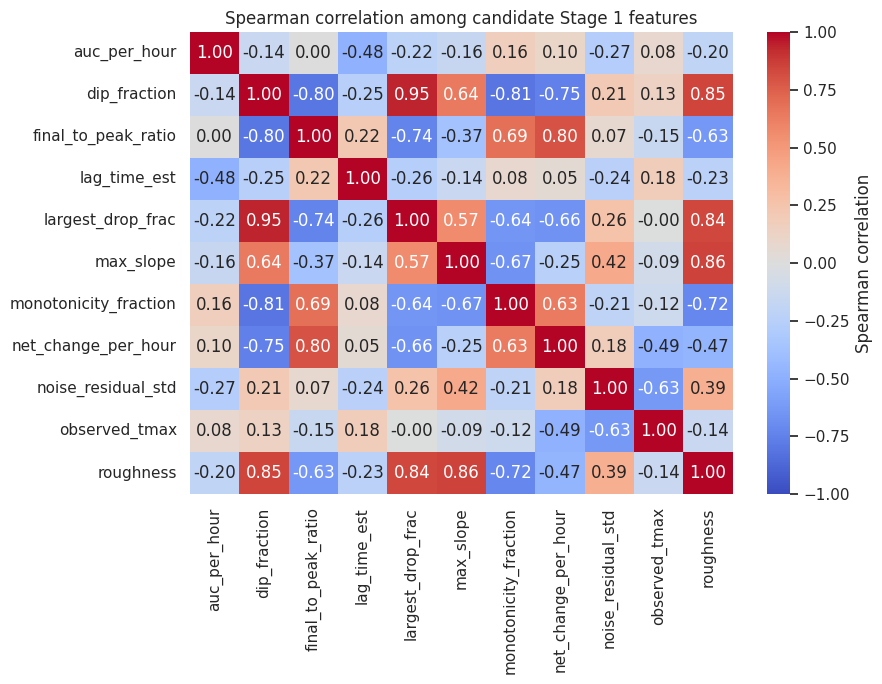

max_slope vs roughness:            r = 0.855
max_slope vs noise_residual_std:    r = 0.416
roughness vs noise_residual_std:    r = 0.386


In [6]:
corr_cols = sorted(set(CANDIDATE_10) | {"noise_residual_std", "auc_per_hour", "dip_fraction"})
corr = X[corr_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax,
            cbar_kws={"label": "Spearman correlation"})
ax.set_title("Spearman correlation among candidate Stage 1 features")
plt.tight_layout()
plt.show()

print("max_slope vs roughness:            r =", round(corr.loc["max_slope", "roughness"], 3))
print("max_slope vs noise_residual_std:    r =", round(corr.loc["max_slope", "noise_residual_std"], 3))
print("roughness vs noise_residual_std:    r =", round(corr.loc["roughness", "noise_residual_std"], 3))

## 6. Model training across feature sets

Each of LR, RF and HGB (the same `build_models()` pipelines used in production training, with
median imputation and `class_weight="balanced"` / `balanced_subsample`) is trained on each of the
three feature sets, on the same group-aware split.

In [7]:
all_results = []
fitted_by_set = {}

for set_name, feats in {"FULL": FULL, "CANDIDATE_10": CANDIDATE_10, "FINAL_8": FINAL_8}.items():
    Xs = X[feats]
    models = build_models()
    res, fitted = fit_and_eval(models, Xs, y, eval_df, train_idx, val_idx, test_idx)
    res["feature_set"] = set_name
    all_results.append(res)
    fitted_by_set[set_name] = fitted

results = pd.concat(all_results, ignore_index=True)
print("Trained %d model/feature-set combinations." % (len(fitted_by_set) * 3))

Trained 9 model/feature-set combinations.


## 7. Performance summary (overall, val + test)

In [8]:
overall = results[results.slice_col == "overall"].copy()
summary = overall[overall.split.isin(["val", "test"])].pivot_table(
    index=["feature_set", "model"], columns="split",
    values=["balanced_acc", "f1", "roc_auc", "pr_auc"],
)
summary = summary.reorder_levels([1, 0], axis=1).sort_index(axis=1, level=0)
summary = summary.round(4)
summary

split                      test                                  val          \
                   balanced_acc      f1  pr_auc roc_auc balanced_acc      f1   
feature_set  model                                                             
CANDIDATE_10 HGB         0.8707  0.8997  0.9265  0.9228       0.8360  0.8757   
             LR          0.8497  0.8877  0.8877  0.8962       0.8224  0.8770   
             RF          0.8760  0.9081  0.9354  0.9336       0.8540  0.9025   
FINAL_8      HGB         0.8636  0.8920  0.9240  0.9188       0.8368  0.8753   
             LR          0.8540  0.8922  0.8746  0.8876       0.8168  0.8771   
             RF          0.8748  0.9086  0.9292  0.9285       0.8452  0.8978   
FULL         HGB         0.8735  0.9028  0.9496  0.9383       0.8387  0.8787   
             LR          0.8483  0.8861  0.9367  0.9214       0.8166  0.8732   
             RF          0.8707  0.9061  0.9455  0.9373       0.8594  0.9082   

split                               
                    pr_auc roc_auc  
feature_set  model                  
CANDIDATE_10 HGB    0.9453  0.9244  
             LR     0.9202  0.8933  
             RF     0.9451  0.9269  
FINAL_8      HGB    0.9453  0.9247  
             LR     0.9129  0.8880  
             RF     0.9445  0.9239  
FULL         HGB    0.9497  0.9277  
             LR     0.9368  0.9114  
             RF     0.9477  0.9288

## 8. Confusion matrices (test split, FINAL_8 feature set)

FINAL_8 is the working feature set intended for the thesis, so its confusion matrices on the held-out
(curve-disjoint) test split are shown here for all three model types.

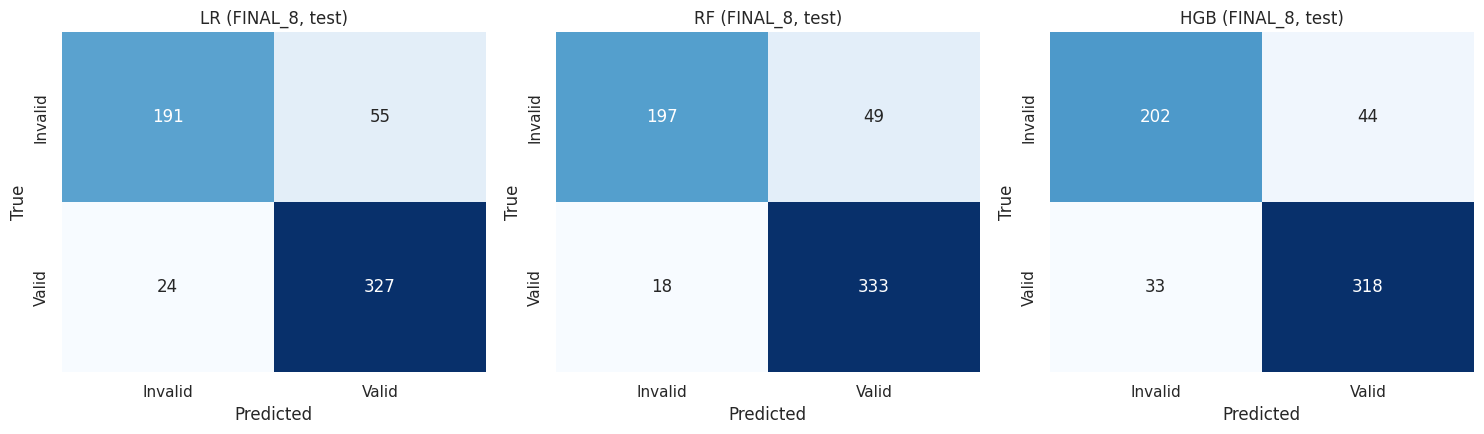

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
X_test = X[FINAL_8].iloc[test_idx]
y_test = y.iloc[test_idx]

for ax, name in zip(axes, ["LR", "RF", "HGB"]):
    model = fitted_by_set["FINAL_8"][name]
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Invalid", "Valid"], yticklabels=["Invalid", "Valid"])
    ax.set_title(f"{name} (FINAL_8, test)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

## 9. ROC curves (test split, FINAL_8 feature set)

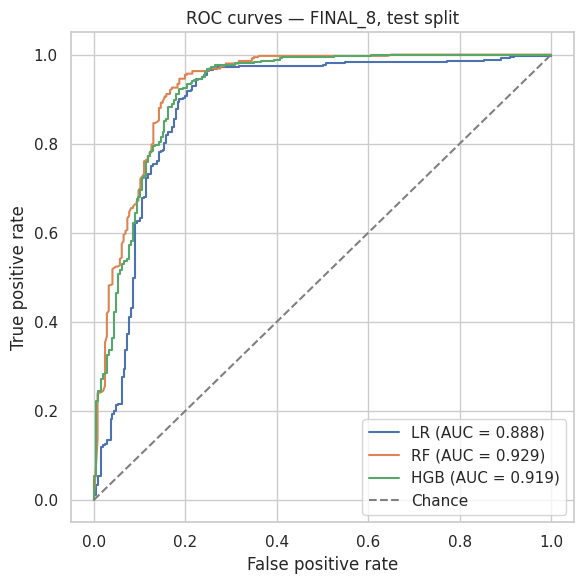

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
for name in ["LR", "RF", "HGB"]:
    model = fitted_by_set["FINAL_8"][name]
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_val:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves — FINAL_8, test split")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 10. Calibration (reliability) curves

This checks whether predicted probabilities on the test split are trustworthy as confidence scores —
directly relevant to the Unsure-threshold logic used downstream.

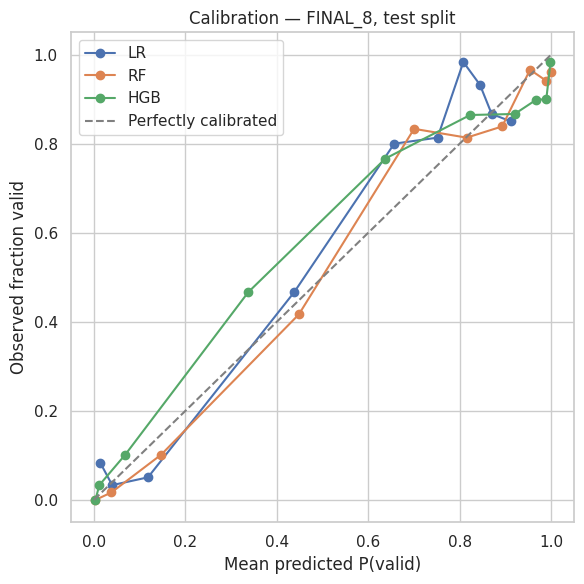

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
for name in ["LR", "RF", "HGB"]:
    model = fitted_by_set["FINAL_8"][name]
    proba = model.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=name)

ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted P(valid)")
ax.set_ylabel("Observed fraction valid")
ax.set_title("Calibration — FINAL_8, test split")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Feature importance and best Valid/Invalid differentiators

Four independent importance signals are computed on the FULL feature set (train split only, to avoid
using test data for feature selection): mutual information, Random Forest impurity importance,
permutation importance on HGB, and absolute LR coefficients (on standardized features). A combined
rank (lower = more important) is used to cross-check `FINAL_8` and `CANDIDATE_10` against a
data-driven ranking rather than only against each other.

In [12]:
X_train_full = X[FULL].iloc[train_idx]
y_train = y.iloc[train_idx]

lr_full = fitted_by_set["FULL"]["LR"]
rf_full = fitted_by_set["FULL"]["RF"]
hgb_full = fitted_by_set["FULL"]["HGB"]

# Mutual information (on median-imputed values, matching what the models see)
imputer = lr_full.named_steps["imputer"]
X_train_imp = pd.DataFrame(imputer.transform(X_train_full), columns=FULL, index=X_train_full.index)

mi = mutual_info_classif(X_train_imp, y_train, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({"Feature": FULL, "Mutual Information": mi})

rf_importance = rf_full.named_steps["clf"].feature_importances_
rf_df = pd.DataFrame({"Feature": FULL, "RF Importance": rf_importance})

lr_coef = np.abs(lr_full.named_steps["clf"].coef_[0])
coef_df = pd.DataFrame({"Feature": FULL, "LR |Coefficient|": lr_coef})

perm = permutation_importance(
    hgb_full, X[FULL].iloc[val_idx], y.iloc[val_idx],
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1,
)
perm_df = pd.DataFrame({"Feature": FULL, "HGB Permutation Importance": perm.importances_mean})

importance = (
    mi_df.merge(rf_df, on="Feature").merge(coef_df, on="Feature").merge(perm_df, on="Feature")
)
for col in ["Mutual Information", "RF Importance", "LR |Coefficient|", "HGB Permutation Importance"]:
    importance[col + " rank"] = importance[col].rank(ascending=False)

importance["Combined Rank Score"] = importance[[c for c in importance.columns if c.endswith("rank")]].sum(axis=1)
importance = importance.sort_values("Combined Rank Score").reset_index(drop=True)
importance["in_FINAL_8"] = importance["Feature"].isin(FINAL_8)
importance["in_CANDIDATE_10"] = importance["Feature"].isin(CANDIDATE_10)

importance.round(4)

,Feature,Mutual Information,RF Importance,LR |Coefficient|,HGB Permutation Importance,Mutual Information rank,RF Importance rank,LR |Coefficient| rank,HGB Permutation Importance rank,Combined Rank Score,in_FINAL_8,in_CANDIDATE_10
0,largest_drop_frac,0.3126,0.1435,1.7526,0.1838,1.0,1.0,2.0,1.0,5.0,True,True
1,net_change_per_hour,0.2550,0.0982,1.4853,0.0157,5.0,2.0,3.0,2.0,12.0,True,True
2,dip_fraction,0.2728,0.0960,1.8522,0.0048,2.0,3.0,1.0,7.0,13.0,False,True
3,initial_OD,0.2066,0.0367,1.4236,0.0049,8.0,8.0,4.0,6.0,26.0,False,False
4,plateau_OD,0.2393,0.0816,0.5008,0.0015,6.0,4.0,10.0,10.0,30.0,False,False
5,noise_residual_std,0.1323,0.0346,1.0364,0.0094,13.0,9.0,6.0,4.0,32.0,False,False
6,max_slope,0.1279,0.0312,0.9742,0.0149,15.0,12.0,7.0,3.0,37.0,True,True
7,monotonicity_fraction,0.1363,0.0301,0.1092,0.0050,12.0,13.0,20.0,5.0,50.0,True,True
8,final_to_peak_ratio,0.2597,0.0701,0.1028,0.0000,4.0,5.0,22.5,19.5,51.0,True,True
9,auc,0.0200,0.0343,0.3880,0.0044,24.0,10.0,12.0,9.0,55.0,False,False


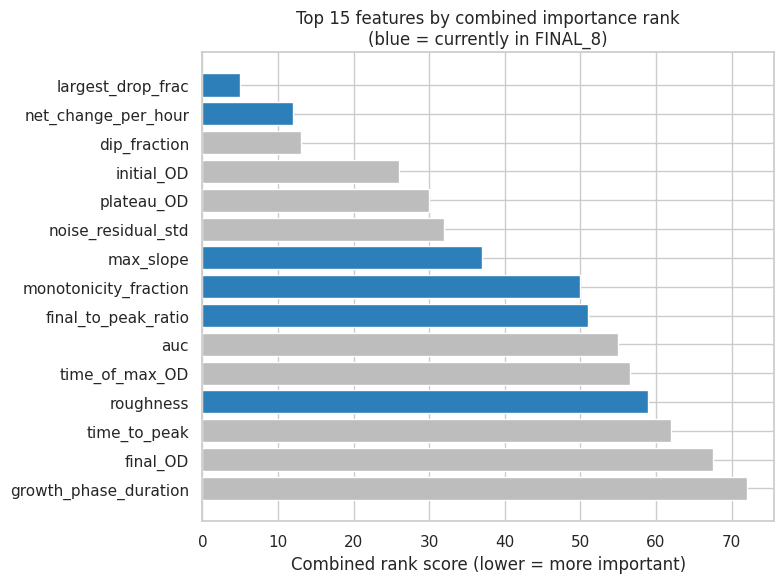

In [13]:
top15 = importance.head(15).sort_values("Combined Rank Score", ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#2c7fb8" if f else "#bdbdbd" for f in top15["in_FINAL_8"]]
ax.barh(top15["Feature"], top15["Combined Rank Score"], color=colors)
ax.set_xlabel("Combined rank score (lower = more important)")
ax.set_title("Top 15 features by combined importance rank\n(blue = currently in FINAL_8)")
plt.tight_layout()
plt.show()

## 12. Ablation: FULL vs CANDIDATE_10 vs FINAL_8

The table below isolates the cost, in test-set performance, of moving from the full feature set down
to the 8-feature set actually used. Reporting this honestly — including if `FINAL_8` underperforms —
is what makes the feature-selection narrative in Chapter 5 defensible.

In [14]:
ablation = overall[overall.split == "test"].pivot_table(
    index="feature_set", columns="model", values=["balanced_acc", "f1", "roc_auc"]
).round(4)
ablation = ablation.reindex(["FULL", "CANDIDATE_10", "FINAL_8"])
ablation

balanced_acc                      f1                 roc_auc  \
model                 HGB      LR      RF     HGB      LR      RF     HGB   
feature_set                                                                 
FULL               0.8735  0.8483  0.8707  0.9028  0.8861  0.9061  0.9383   
CANDIDATE_10       0.8707  0.8497  0.8760  0.8997  0.8877  0.9081  0.9228   
FINAL_8            0.8636  0.8540  0.8748  0.8920  0.8922  0.9086  0.9188   

                              
model             LR      RF  
feature_set                   
FULL          0.9214  0.9373  
CANDIDATE_10  0.8962  0.9336  
FINAL_8       0.8876  0.9285

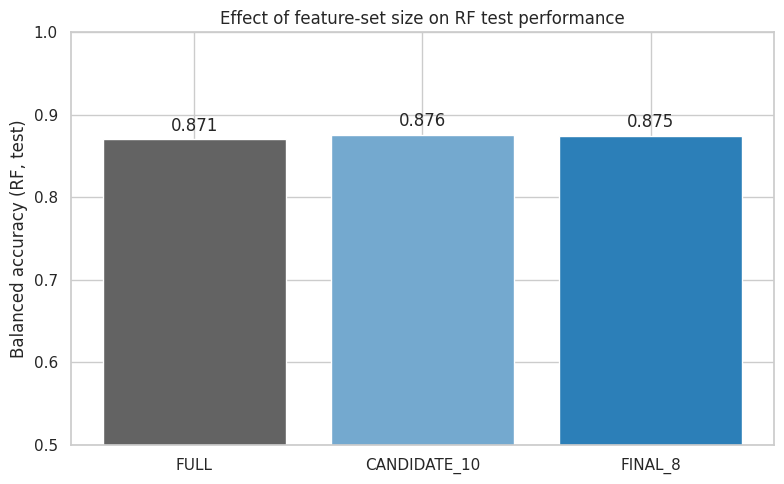

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = overall[(overall.split == "test") & (overall.model == "RF")].set_index("feature_set")
plot_df = plot_df.reindex(["FULL", "CANDIDATE_10", "FINAL_8"])
ax.bar(plot_df.index, plot_df["balanced_acc"], color=["#636363", "#74a9cf", "#2c7fb8"])
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Balanced accuracy (RF, test)")
ax.set_title("Effect of feature-set size on RF test performance")
for i, v in enumerate(plot_df["balanced_acc"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

## 13. Ensemble reproduction & Unsure confidence threshold

Production inference (`infer_labels.py`, `model_name="Average"`) combines the three FINAL_8 models
with certainty-based weighting: each model's per-curve weight is proportional to how far its
predicted P(valid) sits from 0.5, so confident models are trusted more than uncertain ones on a given
curve. That exact weighting scheme is reproduced here on the validation split, and used to sweep the
Unsure confidence threshold. Three values have appeared in the codebase at different times
(0.60, 0.70, 0.80); this sweep is the evidence for picking one as canonical for the thesis.

In [16]:
def certainty_weighted_ensemble(models_dict, X_df):
    probs = []
    for name in ["LR", "RF", "HGB"]:
        p = models_dict[name].predict_proba(X_df)[:, 1]
        probs.append(p)
    probs = np.vstack(probs)  # (3, n)
    eps = 1e-9
    p_clipped = np.clip(probs, eps, 1 - eps)
    certainty = np.abs(p_clipped - 0.5)  # (3, n)
    weights = certainty / certainty.sum(axis=0, keepdims=True)
    avg_valid = np.sum(probs * weights, axis=0)
    return avg_valid

X_val_f8 = X[FINAL_8].iloc[val_idx]
y_val = y.iloc[val_idx]
p_valid_val = certainty_weighted_ensemble(fitted_by_set["FINAL_8"], X_val_f8)

rows = []
for th in [0.60, 0.70, 0.80]:
    valid_th, invalid_th = th, 1 - th
    label = np.where(p_valid_val >= valid_th, "Valid",
             np.where(p_valid_val <= invalid_th, "Invalid", "Unsure"))
    decided = label != "Unsure"
    coverage = decided.mean()
    if decided.sum() > 0:
        pred_bin = (label[decided] == "Valid").astype(int)
        acc_on_decided = (pred_bin == y_val.values[decided]).mean()
    else:
        acc_on_decided = np.nan
    rows.append({
        "threshold": th,
        "coverage (fraction decided)": round(coverage, 4),
        "accuracy on decided curves": round(acc_on_decided, 4),
        "n_unsure": int((~decided).sum()),
    })

threshold_sweep = pd.DataFrame(rows)
threshold_sweep

,threshold,coverage (fraction decided),accuracy on decided curves,n_unsure
0,0.6,0.9497,0.8677,30
1,0.7,0.8811,0.8935,71
2,0.8,0.7337,0.9315,159


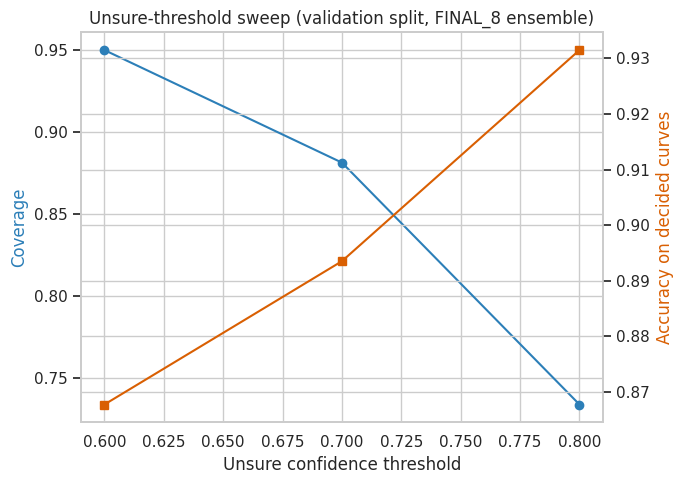

In [17]:
fig, ax1 = plt.subplots(figsize=(7, 5))
ax2 = ax1.twinx()
ax1.plot(threshold_sweep["threshold"], threshold_sweep["coverage (fraction decided)"],
         marker="o", color="#2c7fb8", label="Coverage")
ax2.plot(threshold_sweep["threshold"], threshold_sweep["accuracy on decided curves"],
         marker="s", color="#d95f02", label="Accuracy on decided curves")
ax1.set_xlabel("Unsure confidence threshold")
ax1.set_ylabel("Coverage", color="#2c7fb8")
ax2.set_ylabel("Accuracy on decided curves", color="#d95f02")
ax1.set_title("Unsure-threshold sweep (validation split, FINAL_8 ensemble)")
plt.tight_layout()
plt.show()

## 14. Failure case analysis by curve subtype

`Curve Subtype` (plain / fast / late / diauxic / decline for valid curves; obvious / subtle /
nearreal / decline_only / oscillation / noise / no_growth / collapse for invalid ones) is only
present in the raw synthetic wide file — it is intentionally not carried through the meta-feature
pipeline into `meta.csv` (see Section 1's keep-list), so it is re-attached here purely for
diagnostics, via `Test Id`.

In [18]:
wide_synth = pd.read_csv("data/timeseries_wide_SD1.csv")
subtype_map = wide_synth.set_index("Test Id")["Curve Subtype"]

X_test_full = X[FULL].iloc[test_idx]
test_meta = meta.iloc[test_idx].copy()
test_meta["Curve Subtype"] = test_meta["Test Id"].map(subtype_map).fillna("lab (no subtype)")

rf_f8 = fitted_by_set["FINAL_8"]["RF"]
test_meta["pred"] = rf_f8.predict(X[FINAL_8].iloc[test_idx])
test_meta["correct"] = (test_meta["pred"] == test_meta["Is_Valid"]).astype(int)

failure_by_subtype = (
    test_meta.groupby("Curve Subtype")
    .agg(n=("correct", "size"), accuracy=("correct", "mean"))
    .sort_values("accuracy")
)
failure_by_subtype

,n,accuracy
Curve Subtype,,
invalid_subtle,33,0.272727
invalid_nearreal,24,0.708333
invalid_collapse,42,0.761905
valid_late,36,0.805556
invalid_oscillation,27,0.851852
valid_decline,51,0.862745
invalid_obvious,33,0.909091
invalid_noise,30,0.966667
valid_diauxic,63,0.968254


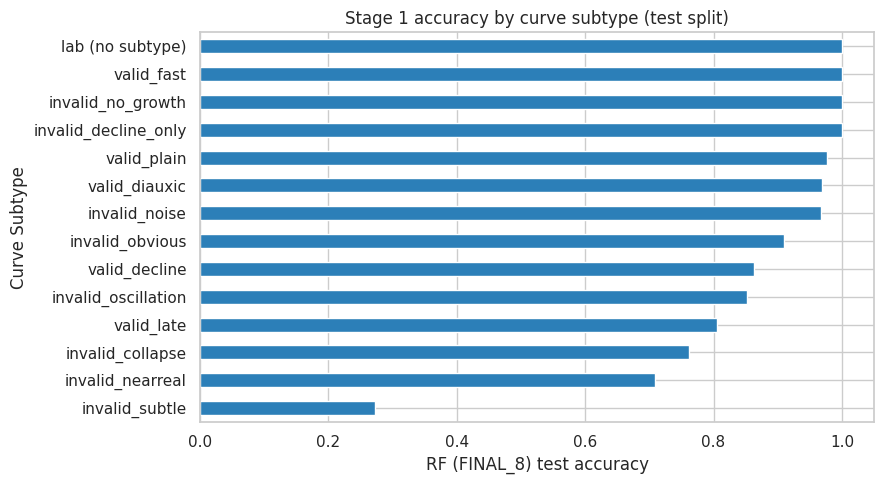

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
failure_by_subtype["accuracy"].plot(kind="barh", ax=ax, color="#2c7fb8")
ax.set_xlabel("RF (FINAL_8) test accuracy")
ax.set_xlim(0, 1.05)
ax.set_title("Stage 1 accuracy by curve subtype (test split)")
plt.tight_layout()
plt.show()

## 15. Saving Stage 1 artifacts (FINAL_8)

This reuses the production `train_from_meta_csv()` function directly (rather than re-implementing
saving logic here) so the artifacts produced are identical in structure to what the CLI/app would
produce, keeping code and thesis in sync.

In [20]:
ART_DIR = Path("classifier_output_notebook_run")
train_out = train_from_meta_csv(
    meta_csv=META_CSV,
    art_dir=ART_DIR,
    run_tag="v03_final8",
    write_lockfile=False,
    selected_features=FINAL_8,
)
print(json.dumps({k: v for k, v in train_out.items() if k not in ("feature_columns",)}, indent=2))

{
  "run_tag": "v03_final8",
  "meta_csv": "data/regen/meta.csv",
  "label_col": "Is_Valid",
  "feature_count": 8,
  "group_split_col": "base_curve_id",
  "model_paths": {
    "LR": "classifier_output_notebook_run/LR_selected_pipeline_v03_final8.joblib",
    "RF": "classifier_output_notebook_run/RF_selected_pipeline_v03_final8.joblib",
    "HGB": "classifier_output_notebook_run/HGB_selected_pipeline_v03_final8.joblib"
  },
  "manifest_paths": {
    "LR": "classifier_output_notebook_run/LR_selected_pipeline_v03_final8.manifest.json",
    "RF": "classifier_output_notebook_run/RF_selected_pipeline_v03_final8.manifest.json",
    "HGB": "classifier_output_notebook_run/HGB_selected_pipeline_v03_final8.manifest.json"
  },
  "selected_features_path": "classifier_output_notebook_run/selected_features_v03_final8.json",
  "thresholds_path": "classifier_output_notebook_run/thresholds_v03_final8.json",
  "results_path": "classifier_output_notebook_run/train_results_selected_v03_final8.csv",
  "lock

## 16. Inference demonstration — Stage 1 (≤16 h) + Stage 2 (>16 h evidence)

Two demo files are used, both generated by the same `growthqa synth` generator used to build the
training data (so they are methodologically consistent with it, not hand-crafted):

- **`lab_plus_synthetic_invalid.csv`** — the real 92-curve lab file (`lab_14.75h_0.25.csv`) with 10
  synthetic invalid curves appended on the same time grid (14.75 h, 0.25 h step). This addresses the
  request to have some invalid curves alongside the lab data for a realistic prediction demo. Because
  this file never exceeds 16 h, Stage 2 has no late-window data on any curve here — every curve gets
  `Insufficient` from the Stage 2 checker, which is the expected, defensible behaviour, not a bug.
- **`timeseries_wide_beyond16h_demo.csv`** — a 36-curve synthetic set generated out to 24 h, so Stage
  1 sees only the first 16 h (as it always does) while Stage 2 has a genuine 16–24 h late window to
  check against.

**Caveat:** neither the real lab file nor the SD1 synthetic file used for training actually extends
past 16 h, so a true Stage 2 demonstration on *real* lab data is not possible with the files
currently available. If you have (or can export) a longer-duration lab acquisition, swap it in here
in place of the synthetic >16 h file for a more convincing Chapter 5 example.

In [21]:
import sys
sys.path.insert(0, "src")
from growthqa.pipelines.infer_labels import run_label_inference_from_uploaded_wide

class Settings:
    input_is_raw = False
    step = 0.25
    min_points = 3
    low_res_threshold = 7
    tmax_hours = 16.0
    auto_tmax = False
    auto_tmax_coverage = 0.8
    clip_negatives = False
    global_blank = None
    smooth_method = "SGF"
    smooth_window = 5
    normalize = "MINMAX"

MODEL_DIR = str(ART_DIR)

demo_lab = pd.read_csv("data/demo/lab_plus_synthetic_invalid.csv")
demo_beyond16h = pd.read_csv("data/demo/timeseries_wide_beyond16h_demo.csv")

out_lab = run_label_inference_from_uploaded_wide(
    wide_df=demo_lab, settings=Settings(), model_dir=MODEL_DIR,
    model_name="Average", stage2_start=16.0,
)
out_b16 = run_label_inference_from_uploaded_wide(
    wide_df=demo_beyond16h, settings=Settings(), model_dir=MODEL_DIR,
    model_name="Average", stage2_start=16.0,
)

print("=== lab_plus_synthetic_invalid.csv (all curves <= 16h) ===")
print(out_lab["out_df"]["Stage 2 Label"].value_counts())
print(out_lab["out_df"]["final_label"].value_counts())
print()
print("=== timeseries_wide_beyond16h_demo.csv (curves extend to 24h) ===")
print(out_b16["out_df"]["Stage 2 Label"].value_counts())
print(out_b16["out_df"]["final_label"].value_counts())

=== lab_plus_synthetic_invalid.csv (all curves <= 16h) ===
Stage 2 Label
Insufficient    102
Name: count, dtype: int64
final_label
Valid      94
Invalid     8
Name: count, dtype: int64

=== timeseries_wide_beyond16h_demo.csv (curves extend to 24h) ===
Stage 2 Label
Corroborated    36
Name: count, dtype: int64
final_label
Valid      22
Invalid    14
Name: count, dtype: int64


In [22]:
cols = ["Test Id", "Predicted S1 Label", "S1 Confidence Valid", "Stage 2 Label", "Label Reason", "final_label"]
print("Sample of the >16h demo predictions (Stage 2 evidence engaged):")
out_b16["out_df"][cols].head(12)

Sample of the >16h demo predictions (Stage 2 evidence engaged):


,Test Id,Predicted S1 Label,S1 Confidence Valid,Stage 2 Label,Label Reason,final_label
0,mo_1,Valid,0.6081,Corroborated,S2_STABLE_OR_PLATEAU,Valid
1,mo_10,Invalid,0.0060,Corroborated,S2_CORROBORATES_INVALID,Invalid
2,mo_11,Invalid,0.0543,Corroborated,S2_CORROBORATES_INVALID,Invalid
3,mo_12,Invalid,0.0034,Corroborated,S2_CORROBORATES_INVALID,Invalid
4,mo_13,Valid,0.7468,Corroborated,S2_STABLE_OR_PLATEAU,Valid
5,mo_14,Invalid,0.0669,Corroborated,S2_CORROBORATES_INVALID,Invalid
6,mo_15,Invalid,0.0046,Corroborated,S2_CORROBORATES_INVALID,Invalid
7,mo_16,Invalid,0.3668,Corroborated,S2_CORROBORATES_INVALID,Invalid
8,mo_17,Valid,0.6761,Corroborated,S2_STABLE_OR_PLATEAU,Valid
9,mo_18,Valid,0.8051,Corroborated,S2_STABLE_OR_PLATEAU,Valid


## 17. Summary for Chapter 5

Points this notebook gives direct evidence for:

- The `source_type` mislabelling bug (Section 1) and its fix — worth a short reproducibility note.
- `FINAL_8` vs `CANDIDATE_10` vs `FULL` performance (Sections 7, 12) — quantifies the cost of the
  8-feature reduction rather than asserting it.
- Feature importance ranking (Section 11) — supports or challenges the specific choice of features
  in `FINAL_8` against a data-driven combined rank.
- Collinearity between `max_slope` and `roughness`, and where `noise_residual_std` sits relative to
  both (Section 5).
- Calibration quality of predicted probabilities (Section 10) — relevant to whether the Unsure
  threshold logic is well-founded.
- Coverage/accuracy trade-off across the three historical threshold values (Section 13) — evidence
  for picking one canonical threshold.
- Per-subtype accuracy (Section 14) — identifies which failure modes (e.g. `diauxic`, `nearreal`)
  are hardest for Stage 1, useful for the limitations discussion.
- A worked Stage 1 + Stage 2 inference example (Section 16), with an explicit caveat that a true
  >16 h *lab* example is still needed.

**Open item:** none of this resolves what exactly was in the missing
`Stage1_Feature_Exploration_Selection_Training_v2.ipynb`. This notebook is offered as its
replacement/reconstruction going forward — if you still have any exported output from the original
(a printed feature ranking, a saved metrics table, even a screenshot), it would be worth cross-checking
against Section 11 above.